In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Paths
BRONZE_DIR = "../data/1_bronze/"
SILVER_DIR = "../data/2_silver/"

# Create silver directory if it doesn't exist
os.makedirs(SILVER_DIR, exist_ok=True)

# Load bronze data
df_students = pd.read_csv(os.path.join(BRONZE_DIR, "students.csv"))
df_schools = pd.read_csv(os.path.join(BRONZE_DIR, "schools.csv"))
df_regions = pd.read_csv(os.path.join(BRONZE_DIR, "regional_stats.csv"))

print("✅ Bronze data loaded successfully")
print(f"Students : {df_students.shape}")
print(f"Schools  : {df_schools.shape}")
print(f"Regions  : {df_regions.shape}")

✅ Bronze data loaded successfully
Students : (1030, 19)
Schools  : (137, 11)
Regions  : (8, 9)


In [94]:
# Remove fully duplicate rows first
df_students = df_students.drop_duplicates()
print(f"✅ Lignes dupliquées supprimées")
print(f"Shape après suppression : {df_students.shape}")

# For duplicate student_ids, keep the first occurrence
df_students = df_students.drop_duplicates(subset='student_id', keep='first')
print(f"✅ student_id dupliqués traités")
print(f"Shape final : {df_students.shape}")

✅ Lignes dupliquées supprimées
Shape après suppression : (1030, 19)
✅ student_id dupliqués traités
Shape final : (1000, 19)


In [95]:
# Strip whitespace from all object columns first
for col in df_students.select_dtypes(include='object').columns:
    df_students[col] = df_students[col].str.strip()

# gender
df_students['gender'] = df_students['gender'].replace({
    'Masculin': 'M', 'MASCULIN': 'M', 'masculin': 'M', 'Homme': 'M', 'homme': 'M',
    'Féminin': 'F', 'FEMININ': 'F', 'feminin': 'F'
})

# grade_level
df_students['grade_level'] = df_students['grade_level'].replace({
    '2ème bac': '2ème Bac', '2eme BAC': '2ème Bac',
    '1ere bac': '1ère Bac', '1 Bac': '1ère Bac',
    'tronc commun': 'Tronc Commun', 'TC': 'Tronc Commun'
})

# status
df_students['status'] = df_students['status'].replace({
    'ADMIS': 'Admis', 'admis': 'Admis', 'Reçu': 'Admis',
    'ajourné': 'Ajourné', 'AJOURNE': 'Ajourné',
    'recalé': 'Recalé'
})

# internet_access
df_students['internet_access'] = df_students['internet_access'].replace({
    'oui': 'Oui', 'OUI': 'Oui', 'yes': 'Oui',
    'non': 'Non', 'NON': 'Non', 'no': 'Non'
})

print("✅ Catégories normalisées\n")

# Verify
for col in ['gender', 'grade_level', 'status', 'internet_access']:
    print(f"--- {col} ---")
    print(df_students[col].value_counts(dropna=False))
    print()

✅ Catégories normalisées

--- gender ---
gender
M      507
F      429
NaN     64
Name: count, dtype: int64

--- grade_level ---
grade_level
2ème Bac        271
Tronc Commun    246
1ère Bac        244
3ème Collège    239
Name: count, dtype: int64

--- status ---
status
Admis      751
Ajourné    233
Recalé      16
Name: count, dtype: int64

--- internet_access ---
internet_access
Non    507
Oui    493
Name: count, dtype: int64



In [96]:
df_students.head()

,student_id,full_name,age,gender,grade_level,school_id,math_score,science_score,french_score,arabic_score,philosophy_score,attendance_pct,study_hours_per_day,internet_access,parent_education,scholarship,enrollment_date,average_score,status
0,STU0340,Aisha Kettani,14,M,3ème Collège,SCH082,12.4,16.6,14.2,17.7,15.4,NaN,4.8,Oui,Primaire,Non,2023-09-21,15.26,Admis
1,STU0245,Sara Berrada,17,F,2ème Bac,SCH094,14.2,10.3,10.9,14.8,16.8,77.5,3.7,Oui,Aucun,Oui,2023-09-11,13.40,Admis
2,STU0883,Othmane Amrani,16,M,1ère Bac,SCH073,13.5,14.8,16.9,10.6,12.6,85.0,4.7,Non,Secondaire,Non,2023-09-18,13.68,Admis
3,STU0568,Loubna El Idrissi,15,M,Tronc Commun,SCH046,12.3,11.8,15.8,10.6,15.4,NaN,3.9,Oui,Primaire,Oui,2023-09-10,13.18,Admis
4,STU0924,Ilyas Tazi,16,M,Tronc Commun,SCH067,14.9,11.0,10.5,17.6,14.8,73.6,4.3,Non,Aucun,Oui,2023-09-09,13.76,Admis


In [97]:
# Step 1 : replace French word numbers with digits
df_students['age'] = df_students['age'].replace({
    'seize': '16',
    'dix-sept': '17'
})

# Step 2 : replace unknown text values with NaN
df_students['age'] = df_students['age'].replace({
    'nr': np.nan,
    'inconnu': np.nan
})

# Step 3 : convert to numeric
df_students['age'] = pd.to_numeric(df_students['age'], errors='coerce')

# Step 4 : replace outliers outside valid range with NaN
df_students.loc[df_students['age'] < 14, 'age'] = np.nan
df_students.loc[df_students['age'] > 19, 'age'] = np.nan

# Verify
print("✅ Colonne age nettoyée\n")
print(df_students['age'].describe())
print(f"\nValeurs manquantes : {df_students['age'].isna().sum()}")

✅ Colonne age nettoyée

count    983.000000
mean      16.066124
std        1.276731
min       14.000000
25%       15.000000
50%       16.000000
75%       17.000000
max       19.000000
Name: age, dtype: float64

Valeurs manquantes : 17


In [98]:
# math_score : replace dirty text values with NaN, convert, remove outliers
df_students['math_score'] = df_students['math_score'].replace({
    'non noté': np.nan, 'n.a': np.nan,
    'absent': np.nan, '?': np.nan, '--': np.nan
})
df_students['math_score'] = pd.to_numeric(df_students['math_score'], errors='coerce')
df_students.loc[df_students['math_score'] < 0, 'math_score'] = np.nan
df_students.loc[df_students['math_score'] > 20, 'math_score'] = np.nan

# attendance_pct : replace dirty text values with NaN, convert, remove outliers
df_students['attendance_pct'] = df_students['attendance_pct'].replace({
    'nr': np.nan, 'n.a.': np.nan,
    '—': np.nan, 'inconnu': np.nan
})
df_students['attendance_pct'] = pd.to_numeric(df_students['attendance_pct'], errors='coerce')
df_students.loc[df_students['attendance_pct'] < 0, 'attendance_pct'] = np.nan
df_students.loc[df_students['attendance_pct'] > 100, 'attendance_pct'] = np.nan

# average_score : replace dirty text values with NaN, convert
df_students['average_score'] = df_students['average_score'].replace({
    'erreur': np.nan, '--': np.nan, 'n.a.': np.nan
})
df_students['average_score'] = pd.to_numeric(df_students['average_score'], errors='coerce')

# study_hours_per_day : remove outliers only (already numeric)
df_students.loc[df_students['study_hours_per_day'] < 0, 'study_hours_per_day'] = np.nan
df_students.loc[df_students['study_hours_per_day'] > 16, 'study_hours_per_day'] = np.nan

# Verify
print("✅ Colonnes numériques nettoyées\n")
for col in ['math_score', 'attendance_pct', 'average_score', 'study_hours_per_day']:
    print(f"--- {col} ---")
    print(f"min={df_students[col].min()}, max={df_students[col].max()}, NaN={df_students[col].isna().sum()}")
    print()

✅ Colonnes numériques nettoyées

--- math_score ---
min=2.1, max=19.0, NaN=1

--- attendance_pct ---
min=55.0, max=100.0, NaN=101

--- average_score ---
min=3.58, max=17.06, NaN=0

--- study_hours_per_day ---
min=0.5, max=7.0, NaN=0



In [99]:
# Convert all date formats to YYYY-MM-DD
df_students['enrollment_date'] = pd.to_datetime(
    df_students['enrollment_date'],
    dayfirst=True,
    errors='coerce'
)

# Verify
print("✅ Dates standardisées\n")
print(df_students['enrollment_date'].dtype)
print(df_students['enrollment_date'].head(10))
print(f"\nValeurs manquantes : {df_students['enrollment_date'].isna().sum()}")

✅ Dates standardisées

datetime64[ns]
0   2023-09-21
1   2023-09-11
2   2023-09-18
3   2023-09-10
4   2023-09-09
5   2023-09-02
6   2023-09-01
7   2023-09-04
8          NaT
9   2023-09-18
Name: enrollment_date, dtype: datetime64[ns]

Valeurs manquantes : 175


C:\Users\user\AppData\Local\Temp\ipykernel_3896\1142581514.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_students['enrollment_date'] = pd.to_datetime(


In [100]:
# Reset index first so it goes 0, 1, 2, 3...
df_students = df_students.reset_index(drop=True)

# List of male first names
male_names = [
    'khalid', 'tariq', 'rachid', 'mehdi', 'mouad', 'omar', 'youssef',
    'amine', 'karim', 'hamza', 'ilyas', 'othmane', 'adam', 'bilal',
    'soufiane', 'ayoub', 'zakaria', 'saad', 'anass', 'reda', 'nabil',
    'hicham', 'fouad', 'abdelhamid', 'mostafa', 'hassan', 'ahmed', 'adil'
]

# List of female first names
female_names = [
    'houda', 'lina', 'sara', 'fatima', 'zineb', 'nadia', 'samira',
    'aisha', 'loubna', 'rim', 'salma', 'hafsa', 'meryem', 'khadija',
    'nour', 'widad', 'imane', 'soukaina', 'chaimae', 'asma', 'hana',
    'yasmine', 'layla', 'siham', 'najat', 'boutaina', 'manal', 'hajar', 'ghita'
]

# Go through each row and assign gender based on first name
for i in range(len(df_students)):
    first_name = str(df_students.loc[i, 'full_name']).split()[0].lower()
    if first_name in male_names:
        df_students.loc[i, 'gender'] = 'M'
    elif first_name in female_names:
        df_students.loc[i, 'gender'] = 'F'

# Fill any remaining unknowns with mode
df_students['gender'] = df_students['gender'].fillna(df_students['gender'].mode()[0])

print("✅ Genre corrigé et imputé par prénom\n")
print(df_students['gender'].value_counts(dropna=False))

✅ Genre corrigé et imputé par prénom

gender
M    509
F    491
Name: count, dtype: int64


In [101]:
# Check distribution and skewness before imputation
numeric_cols = ['age', 'math_score', 'french_score', 
                'attendance_pct', 'study_hours_per_day', 'average_score']

print("=== Skewness des colonnes numériques ===\n")
for col in numeric_cols:
    skewness = df_students[col].skew()
    if abs(skewness) < 0.5:
        method = "→ MEAN (distribution symétrique)"
    else:
        method = "→ MEDIAN (distribution asymétrique)"
    print(f"{col:25} : skewness = {round(skewness, 2):6}  {method}")

=== Skewness des colonnes numériques ===

age                       : skewness =   0.03  → MEAN (distribution symétrique)
math_score                : skewness =  -0.19  → MEAN (distribution symétrique)
french_score              : skewness =  -0.22  → MEAN (distribution symétrique)
attendance_pct            : skewness =   0.14  → MEAN (distribution symétrique)
study_hours_per_day       : skewness =   -0.4  → MEAN (distribution symétrique)
average_score             : skewness =  -0.96  → MEDIAN (distribution asymétrique)


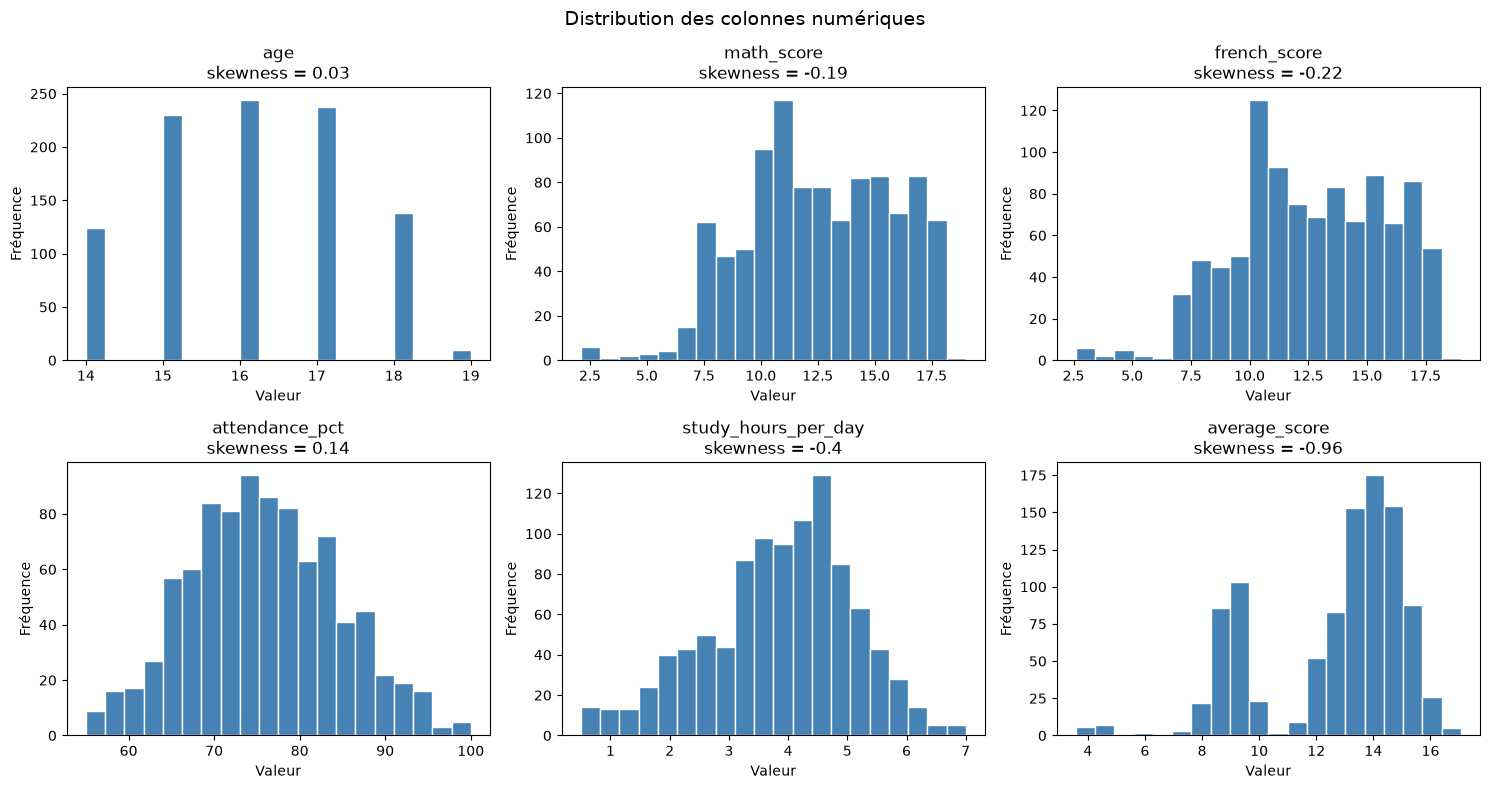

In [102]:
import matplotlib.pyplot as plt

# Visualize distribution of each numeric column
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_students[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\nskewness = {round(df_students[col].skew(), 2)}')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des colonnes numériques', fontsize=14)
plt.tight_layout()
plt.show()

In [103]:
# Impute age with median per grade_level group
df_students['age'] = df_students.groupby('grade_level')['age'].transform(
    lambda x: x.fillna(x.median())
)

print("✅ Age imputé par groupe grade_level\n")
print(df_students.groupby('grade_level')['age'].median())
print(f"\nValeurs manquantes restantes : {df_students['age'].isna().sum()}")

✅ Age imputé par groupe grade_level

grade_level
1ère Bac        16.0
2ème Bac        18.0
3ème Collège    15.0
Tronc Commun    16.0
Name: age, dtype: float64

Valeurs manquantes restantes : 0


In [104]:
# Impute math_score with median per grade_level group
df_students['math_score'] = df_students.groupby('grade_level')['math_score'].transform(
    lambda x: x.fillna(x.median())
)

# Impute french_score with median per grade_level group
df_students['french_score'] = df_students.groupby('grade_level')['french_score'].transform(
    lambda x: x.fillna(x.median())
)

print("✅ math_score et french_score imputés par grade_level\n")
print("Médiane math_score par niveau:")
print(df_students.groupby('grade_level')['math_score'].median())
print("\nMédiane french_score par niveau:")
print(df_students.groupby('grade_level')['french_score'].median())
print(f"\nNaN math_score  : {df_students['math_score'].isna().sum()}")
print(f"NaN french_score : {df_students['french_score'].isna().sum()}")

✅ math_score et french_score imputés par grade_level

Médiane math_score par niveau:
grade_level
1ère Bac        12.4
2ème Bac        12.6
3ème Collège    12.4
Tronc Commun    12.4
Name: math_score, dtype: float64

Médiane french_score par niveau:
grade_level
1ère Bac        12.3
2ème Bac        12.7
3ème Collège    13.2
Tronc Commun    12.5
Name: french_score, dtype: float64

NaN math_score  : 0
NaN french_score : 0


In [105]:
# Impute attendance_pct with median per school group
df_students['attendance_pct'] = df_students.groupby('school_id')['attendance_pct'].transform(
    lambda x: x.fillna(x.median())
)

print("✅ attendance_pct imputé par school_id\n")
print(f"NaN restants : {df_students['attendance_pct'].isna().sum()}")

✅ attendance_pct imputé par school_id

NaN restants : 0


In [106]:
# Impute study_hours_per_day with median per grade_level group
df_students['study_hours_per_day'] = df_students.groupby('grade_level')['study_hours_per_day'].transform(
    lambda x: x.fillna(x.median())
)

print("✅ study_hours_per_day imputé par grade_level\n")
print("Médiane study_hours par niveau:")
print(df_students.groupby('grade_level')['study_hours_per_day'].median())
print(f"\nNaN restants : {df_students['study_hours_per_day'].isna().sum()}")

✅ study_hours_per_day imputé par grade_level

Médiane study_hours par niveau:
grade_level
1ère Bac        4.0
2ème Bac        3.8
3ème Collège    4.1
Tronc Commun    4.0
Name: study_hours_per_day, dtype: float64

NaN restants : 0


In [107]:
# Global mode of parent_education
mode_parent_education = df_students['parent_education'].mode()[0]
print(f"Mode global : {mode_parent_education}")

# Impute missing values with mode
df_students['parent_education'] = df_students['parent_education'].fillna(mode_parent_education)

print("✅ parent_education imputé par le mode global\n")
print(df_students['parent_education'].value_counts(dropna=False))
print(f"\nNaN restants : {df_students['parent_education'].isna().sum()}")

Mode global : Aucun
✅ parent_education imputé par le mode global

parent_education
Aucun         314
Primaire      243
Supérieur     228
Secondaire    215
Name: count, dtype: int64

NaN restants : 0


In [108]:
# Impute scholarship with mode per parent_education group
df_students['scholarship'] = df_students.groupby('parent_education')['scholarship'].transform(
    lambda x: x.fillna(x.mode()[0])
)

print("✅ scholarship imputé par groupe parent_education\n")
print(df_students.groupby('parent_education')['scholarship'].value_counts())
print(f"\nNaN restants : {df_students['scholarship'].isna().sum()}")

✅ scholarship imputé par groupe parent_education

parent_education  scholarship
Aucun             Oui            207
                  Non            107
Primaire          Oui            175
                  Non             68
Secondaire        Non            108
                  Oui            107
Supérieur         Non            162
                  Oui             66
Name: count, dtype: int64

NaN restants : 0


In [109]:
# Impute average_score with mean of 5 subjects
df_students['average_score'] = df_students.apply(
    lambda row: round((row['math_score'] + row['science_score'] + 
                       row['french_score'] + row['arabic_score'] + 
                       row['philosophy_score']) / 5, 2)
    if pd.isna(row['average_score']) else row['average_score'],
    axis=1
)

print("✅ average_score imputé par la moyenne des 5 matières\n")
print(df_students['average_score'].describe())
print(f"\nNaN restants : {df_students['average_score'].isna().sum()}")

✅ average_score imputé par la moyenne des 5 matières

count    1000.000000
mean       12.619120
std         2.542121
min         3.580000
25%        10.020000
50%        13.500000
75%        14.480000
max        17.060000
Name: average_score, dtype: float64

NaN restants : 0


In [110]:
# Impute missing enrollment_date with the most frequent date
mode_date = df_students['enrollment_date'].mode()[0]
df_students['enrollment_date'] = df_students['enrollment_date'].fillna(mode_date)

print("✅ enrollment_date imputé par le mode\n")
print(f"Mode utilisé : {mode_date}")
print(f"NaN restants : {df_students['enrollment_date'].isna().sum()}")

✅ enrollment_date imputé par le mode

Mode utilisé : 2023-09-17 00:00:00
NaN restants : 0


In [111]:
print("=== BILAN FINAL DU NETTOYAGE ===\n")
print(f"Shape final : {df_students.shape}")
print(f"\nValeurs manquantes restantes :")
print(df_students.isnull().sum())

=== BILAN FINAL DU NETTOYAGE ===

Shape final : (1000, 19)

Valeurs manquantes restantes :
student_id             0
full_name              0
age                    0
gender                 0
grade_level            0
school_id              0
math_score             0
science_score          0
french_score           0
arabic_score           0
philosophy_score       0
attendance_pct         0
study_hours_per_day    0
internet_access        0
parent_education       0
scholarship            0
enrollment_date        0
average_score          0
status                 0
dtype: int64


In [112]:
# Save cleaned dataframe to silver layer
df_students.to_csv('../data/2_silver/students_silver.csv', index=False)

print("✅ Fichier sauvegardé dans data/2_silver/students_silver.csv")
print(f"Shape : {df_students.shape}")

✅ Fichier sauvegardé dans data/2_silver/students_silver.csv
Shape : (1000, 19)


In [113]:
# Schools and regional were already clean, just copy to silver
df_schools.to_csv('../data/2_silver/schools_silver.csv', index=False)
df_regions.to_csv('../data/2_silver/regional_stats_silver.csv', index=False)

print("✅ schools_silver.csv sauvegardé")
print("✅ regional_stats_silver.csv sauvegardé")

✅ schools_silver.csv sauvegardé
✅ regional_stats_silver.csv sauvegardé
